In [ ]:
!pip install -q striprtf tqdm

In [ ]:
import os
import glob
import pandas as pd

from tqdm import tqdm
from striprtf.striprtf import rtf_to_text

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_path = "/content/drive/MyDrive/LexisNexis_01july2026/New1"

In [ ]:
files = glob.glob(
    os.path.join(folder_path, "*.RTF")
)

files += glob.glob(
    os.path.join(folder_path, "*.rtf")
)

print(f"Total Files Found : {len(files)}")

Total Files Found : 941


In [ ]:

documents = []
filenames = []

for file in tqdm(files):

    try:

        with open(
            file,
            "r",
            encoding="utf-8",
            errors="ignore"
        ) as f:

            text = rtf_to_text(f.read())

        text = text.strip()

        if len(text) > 50:

            documents.append(text)

            filenames.append(
                os.path.basename(file)
            )

    except Exception:

        pass

100%|██████████| 941/941 [01:32<00:00, 10.13it/s]


In [ ]:
df = pd.DataFrame({

    "Filename": filenames,

    "Document": documents

})

print(df.shape)

df.head()

(941, 2)


,Filename,Document
0,Files (499)_doclist.RTF,User Name: = staff_id@iitd.ac.in\nDate and Tim...
1,"Sagar Adani Calls for Faster Electrification, ...","Sagar Adani Calls for Faster Electrification, ..."
2,"Adani Enterprises_ A high-risk, high-reward be...","Adani Enterprises: A high-risk, high-reward be..."
3,"Adani, Jabil Plan AI Infrastructure Manufactur...","Adani, Jabil Plan AI Infrastructure Manufactur..."
4,Reliance and Meta Partner to Develop AI-Enable...,Reliance and Meta Partner to Develop AI-Enable...


In [ ]:
df["Length"] = df["Document"].apply(
    lambda x: len(x.split())
)

print(df["Length"].describe())

count      941.000000
mean      1328.797024
std       3167.048542
min         45.000000
25%        505.000000
50%        786.000000
75%       1144.000000
max      42782.000000
Name: Length, dtype: float64


In [ ]:
df = df[
    df["Length"] >= 30
].reset_index(drop=True)

documents = df["Document"].tolist()

print("Remaining Documents :", len(documents))

Remaining Documents : 941


In [ ]:
df.to_csv(
    "Raw_Documents.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
!pip install -q spacy nltk contractions
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 78.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import string
import unicodedata
import contractions
import nltk
import spacy

from nltk.corpus import stopwords
from tqdm import tqdm

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner"]
)

In [ ]:
stop_words = set(stopwords.words("english"))

extra_stopwords = {

    "said","say","says",
    "also","may","might",
    "would","could","new",

    "news","year","today",

    "company","companies",
    "business","market",
    "global","industry",

    "copyright","reserved",
    "rights","distributed",

    "body","length","section",

    "monday","tuesday","wednesday",
    "thursday","friday","saturday","sunday",

    "january","february","march",
    "april","may","june",
    "july","august",
    "september","october",
    "november","december",
     "copyright",

    "dateline","body","edition",
    "section", "length","word",

    "words",

    "llc",

    "newswire",

    "prnewswire",

    "businesswire",

    "business",

    "wire",

    "association",

    "com",

    "est",

    "gmt",

    "utc",

    "news",

    "source",

    "sources",

    "commentary"


}

stop_words.update(extra_stopwords)

In [ ]:
custom_lemmas = {

    "companies":"company",
    "technologies":"technology",
    "industries":"industry",

    "organizations":"organization",
    "organisation":"organization",
    "organisations":"organization",

    "universities":"university",

    "students":"student",

    "markets":"market",

    "customers":"customer",

    "suppliers":"supplier",

    "services":"service",

    "centre":"center",
    "centres":"center",

    "labs":"lab",

    "prof":"professor",

    "chemours":"chemour"
}

In [ ]:
def clean_text(text):

    # Expand contractions
    text = contractions.fix(text)

    # Unicode normalization
    text = unicodedata.normalize("NFKD", text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove Emails
    text = re.sub(r"\S+@\S+", " ", text)

    # Remove HTML
    text = re.sub(r"<.*?>", " ", text)

    # Remove RTF artifacts
    text = re.sub(r"\\[a-z]+\d*", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove punctuation & special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
def preprocess(text):

    text = clean_text(text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.is_stop:
            continue

        if token.like_num:
            continue

        if token.is_punct:
            continue

        lemma = token.lemma_.lower()

        # Custom Lemma
        lemma = custom_lemmas.get(
            lemma,
            lemma
        )

        if lemma in stop_words:
            continue

        if len(lemma) < 3:
            continue

        if not lemma.isalpha():
            continue

        tokens.append(lemma)

    return " ".join(tokens)

In [ ]:
processed_docs = []

for doc in tqdm(documents, desc="Preprocessing"):

    processed_docs.append(preprocess(doc))

Preprocessing: 100%|██████████| 941/941 [01:30<00:00, 10.35it/s]


In [ ]:
tokenized_docs = [

    doc.split()

    for doc in processed_docs

]

print("Tokenized Documents :", len(tokenized_docs))

Tokenized Documents : 941


In [ ]:
# Remove copyright block
text = re.sub(r"copyright.*?(?=body|dateline|length)", " ", text, flags=re.DOTALL)

# Remove PR Newswire / Business Wire metadata
text = re.sub(r"dateline.*?(?=body)", " ", text, flags=re.DOTALL)

text = re.sub(r"length\s*:?\s*\d+\s*words?", " ", text)

text = re.sub(r"edition.*", " ", text)

text = re.sub(r"section.*", " ", text)

text = re.sub(r"body", " ", text)

text = re.sub(r"byline.*", " ", text)

text = re.sub(r"source.*", " ", text)

text = re.sub(r"newswire", " ", text)

text = re.sub(r"prnewswire", " ", text)

text = re.sub(r"business wire", " ", text)

text = re.sub(r"globe newswire", " ", text)

text = re.sub(r"all rights reserved", " ", text)

text = re.sub(r"rights reserved", " ", text)

text = re.sub(r"right reserve", " ", text)

In [ ]:

tokenized_docs = [doc.split() for doc in processed_docs]

In [ ]:
# ============================================================
# Automatic Vocabulary Cleaning using Document Frequency
# ============================================================

from collections import Counter
from tqdm import tqdm

# Count how many documents contain each word
document_frequency = Counter()

for doc in tqdm(tokenized_docs, desc="Calculating Document Frequency"):

    # Count each word only once per document
    unique_words = set(doc)

    for word in unique_words:
        document_frequency[word] += 1

TOTAL_DOCS = len(tokenized_docs)

# ------------------------------------------------------------
# Automatic Thresholds
# ------------------------------------------------------------

# Remove words appearing in less than 3 documents
MIN_DF = max(3, int(TOTAL_DOCS * 0.002))

# Remove words appearing in more than 80% documents
MAX_DF_RATIO = 0.80

automatic_stopwords = set()

for word, df in document_frequency.items():

    df_ratio = df / TOTAL_DOCS

    # Remove very rare words
    if df < MIN_DF:
        automatic_stopwords.add(word)

    # Remove very common words
    elif df_ratio > MAX_DF_RATIO:
        automatic_stopwords.add(word)

print("Automatic Stopwords:", len(automatic_stopwords))

# ------------------------------------------------------------
# Remove automatic stopwords
# ------------------------------------------------------------

filtered_docs = []

for doc in tqdm(tokenized_docs, desc="Filtering Documents"):

    filtered = [

        word

        for word in doc

        if word not in automatic_stopwords

    ]

    filtered_docs.append(filtered)

# Convert back to text

processed_docs = [

    " ".join(doc)

    for doc in filtered_docs

]

tokenized_docs = filtered_docs

print("Vocabulary cleaned successfully.")

Calculating Document Frequency: 100%|██████████| 941/941 [00:00<00:00, 5724.55it/s]


Automatic Stopwords: 17344


Filtering Documents: 100%|██████████| 941/941 [00:00<00:00, 14177.53it/s]

Vocabulary cleaned successfully.


In [ ]:
print(processed_docs[0][:1000])

user time job number client matter search term artificial intelligence machine learning alliance partnership collaboration joint venture sustainability green esg clean search type content type narrow sagar adani call fast electrification renewable energy storage drive clean energy transition adani enterprise high risk high reward bet faint hearted sudip bandyopadhyay adani put nuclear power datum center center expansion push jio ipo trigger mukesh ambani line revive reliance share lakh investor accessory cheap bear ray ban oakley brand naver expand infrastructure nvidia meta glass come spain line power glass feature different style jeff bezos create job opportunity reliance agm look big move announce ambanis annual meeting france foxconn nvidia france attractive europe infrastructure reliance agm ambani declare war avocados jio boost mukesh ambani ril agm speech highlight reliance agm jio ipo strategy energy roadmap key trigger focus adani enterprise jabil plan massive datum center man

In [ ]:
# Install Sentence Transformers
!pip install -q sentence-transformers

In [ ]:
# ==========================================================
# STEP 4 : Generate Sentence Embeddings
# ==========================================================

# Import the SentenceTransformer class.
# It is used to convert each document into a dense semantic vector.
# These vectors capture the contextual meaning of the documents and
# are later used by BERTopic for clustering similar documents.

from sentence_transformers import SentenceTransformer

In [ ]:

# ----------------------------------------------------------
# Load the Pre-trained Sentence Embedding Model
# ----------------------------------------------------------

# all-MiniLM-L6-v2 is a lightweight and efficient transformer model.
# It converts every document into a 384-dimensional semantic vector.
#
# Advantages:
# • Fast embedding generation
# • Good semantic understanding
# • Recommended by BERTopic documentation
# • Suitable for medium-sized datasets

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
# ----------------------------------------------------------
# Generate Semantic Embeddings
# ----------------------------------------------------------

# Convert every preprocessed document into a semantic embedding.
#
# Parameters:
#
# processed_docs
#     List of cleaned documents.
#
# batch_size=32
#     Number of documents processed together.
#     Larger values increase speed but require more RAM.
#
# show_progress_bar=True
#     Displays the embedding generation progress.
#
# convert_to_numpy=True
#     Returns embeddings as NumPy arrays, which are required by BERTopic.

embeddings = embedding_model.encode(

    processed_docs,

    batch_size=32,

    show_progress_bar=True,

    convert_to_numpy=True

)

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
# ----------------------------------------------------------
# Verify Embedding Dimensions
# ----------------------------------------------------------

# Display the shape of the generated embedding matrix.
#
# Expected Output:
# (Number of Documents, Embedding Dimension)
#
# Example:
# (1620, 384)

print("Embedding Matrix Shape :", embeddings.shape)

Embedding Matrix Shape : (941, 384)


In [ ]:
# ----------------------------------------------------------
# Save Embeddings
# ----------------------------------------------------------

# Saving embeddings avoids regenerating them every time
# the notebook is executed.

import numpy as np

np.save(
    "document_embeddings.npy",
    embeddings
)

print("Embeddings saved successfully.")

Embeddings saved successfully.


In [ ]:
# ==========================================================
# Install Required Libraries
# ==========================================================

# Install BERTopic and its required dependencies.
# Run this cell only once in a new runtime.
# After installation, restart the runtime before importing the libraries.

!pip install -q bertopic umap-learn hdbscan sentence-transformers

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# BERTopic performs topic modeling using transformer embeddings.
from bertopic import BERTopic

# UMAP reduces embedding dimensions while preserving semantic structure.
from umap import UMAP

# HDBSCAN clusters semantically similar document embeddings.
from hdbscan import HDBSCAN

# SentenceTransformer generates contextual document embeddings.
from sentence_transformers import SentenceTransformer

# Pandas is used for data manipulation and analysis.
import pandas as pd

# NumPy supports numerical computations.
import numpy as np

# Regular expressions are used for text preprocessing.
import re

# OS module is used for file and directory operations.
import os

# Collections provide efficient data structures such as Counter.
from collections import Counter, defaultdict

# Math module is used for logarithmic calculations.
import math



In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from collections import Counter, defaultdict

In [ ]:
# ==========================================================
# Check Computing Device
# ==========================================================

# Import PyTorch.
import torch

# Display whether CUDA is available.
print("CUDA Available :", torch.cuda.is_available())

# Display the current computation device.
print("Device :", "GPU" if torch.cuda.is_available() else "CPU")

CUDA Available : True
Device : GPU


In [ ]:
# ----------------------------------------------------------
# Configure HDBSCAN
# ----------------------------------------------------------

# HDBSCAN groups semantically similar documents.

hdbscan_model = HDBSCAN(

    # Minimum documents required to form one topic.
    min_cluster_size=8,

    # Controls clustering strictness.
    min_samples=2,

    # Euclidean distance works well after UMAP reduction.
    metric="euclidean",

    # Stores prediction information.
    prediction_data=True

)

In [ ]:

# ----------------------------------------------------------
# Configure CountVectorizer
# ----------------------------------------------------------

# CountVectorizer builds the vocabulary used for c-TF-IDF.

vectorizer_model = CountVectorizer(

    # Ignore words appearing in fewer than 3 documents.
    min_df=4,

    # Ignore words appearing in more than 80% of documents.
    max_df=0.80,

    # Consider single words only.
    ngram_range=(1,1)

)

In [ ]:
# ==========================================================
# Configure UMAP
# ==========================================================

from umap import UMAP

umap_model = UMAP(
    n_neighbors=17,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

In [ ]:
# ----------------------------------------------------------
# Initialize BERTopic
# ----------------------------------------------------------

# Create the BERTopic model using the customized
# UMAP, HDBSCAN and CountVectorizer.

topic_model = BERTopic(

    embedding_model=embedding_model,

    umap_model=umap_model,

    hdbscan_model=hdbscan_model,

    vectorizer_model=vectorizer_model,

    # Store the top 20 keywords for each topic.
    top_n_words=20,

    # Ignore topics smaller than 10 documents.
    min_topic_size=10,

    # Probability calculation is disabled to reduce memory usage.
    calculate_probabilities=False,

    # Display training progress.
    verbose=True

)

In [ ]:
# ----------------------------------------------------------
# Train BERTopic
# ----------------------------------------------------------

# Discover topics using the preprocessed documents
# and the generated sentence embeddings.

topics, probabilities = topic_model.fit_transform(

    processed_docs,

    embeddings

)

2026-07-03 07:08:06,371 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-03 07:08:09,462 - BERTopic - Dimensionality - Completed ✓
2026-07-03 07:08:09,464 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-03 07:08:09,522 - BERTopic - Cluster - Completed ✓
2026-07-03 07:08:09,529 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 07:08:09,962 - BERTopic - Representation - Completed ✓


In [ ]:
# ----------------------------------------------------------
# Topic Information
# ----------------------------------------------------------

topic_info = topic_model.get_topic_info()
topic_info.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,185,-1_gaap_accenture_non_quarter,"[gaap, accenture, non, quarter, benz, mercedes...",[tesla suffer hit unveil car steering wheel te...
1,0,50,0_india_summit_minister_gate,"[india, summit, minister, gate, pradesh, naidu...",[modi hail excellent meeting bill gate viksit ...
2,1,39,1_reliance_ambani_jio_india,"[reliance, ambani, jio, india, agm, meta, ril,...",[ril agm jio ipo reliance intelligence mission...
3,2,33,2_visakhapatnam_adani_hub_andhra,"[visakhapatnam, adani, hub, andhra, pradesh, i...",[adani google collaborate develop datum center...
4,3,29,3_schneider_electric_france_factory,"[schneider, electric, france, factory, cool, f...",[schneider electric accelerate development dep...


In [ ]:
# ----------------------------------------------------------
# Display Topics and Their Keywords
# ----------------------------------------------------------

for topic_id in topic_model.get_topics():

    if topic_id == -1:
        continue

    keywords = [word for word, _ in topic_model.get_topic(topic_id)]

    print(f"Topic {topic_id}")
    print(", ".join(keywords))
    print()

Topic 0
india, summit, minister, gate, pradesh, naidu, andhra, delhi, bill, indian, pakistan, health, host, discussion, modi, meeting, davos, south, prime, healthcare

Topic 1
reliance, ambani, jio, india, agm, meta, ril, mukesh, crore, ipo, indian, jamnagar, adani, tms, gigawatt, lakh, financieras, menafn, venture, ready

Topic 2
visakhapatnam, adani, hub, andhra, pradesh, india, adaniconnex, airtel, subsea, clean, gigawatt, cable, campus, capacity, kurian, faceted, gautam, joint, nation, storage

Topic 3
schneider, electric, france, factory, cool, french, liquid, rack, marketing, dassault, paris, europe, half, client, syste, activity, european, expertise, wave, sustainable

Topic 4
musk, openai, trump, stargate, altman, abilene, elon, sam, clash, tesla, krishnan, claim, softbank, write, america, donald, chatgpt, court, spacex, lawsuit

Topic 5
trump, action, administration, american, america, white, race, european, house, watch, europe, davos, federal, government, tariff, surprise, t

In [ ]:
# ==========================================================
# STEP 6 : Hybrid Keyword Ranking
# ==========================================================

# Import Counter to calculate Document Frequency (DF).
# Counter counts how many documents contain each keyword.
from collections import Counter

# Import defaultdict to count in how many topics
# each keyword appears.
from collections import defaultdict

# Import math to use the logarithmic function.
# log(1 + DF) prevents very common words from
# dominating the ranking.
import math

# Import regular expressions for token extraction.
import re

In [ ]:
# ==========================================================
# Calculate Topic Exclusiveness
# ==========================================================

# This dictionary stores how many topics contain each keyword.
# Words appearing in many topics are considered less exclusive.

word_topic_count = defaultdict(int)

# Iterate through every discovered topic.
for topic_id, topic_words in topic_model.get_topics().items():

    # Skip the outlier topic.
    if topic_id == -1:
        continue

    # Count each keyword once for every topic.
    for word, score in topic_words:

        word_topic_count[word.lower()] += 1

In [ ]:
# ==========================================================
# Display Topic Exclusiveness
# ==========================================================

# Display the first few keywords and the number of topics
# in which they appear.

for word in list(word_topic_count.keys())[:10]:

    print(f"{word:20s} {word_topic_count[word]}")

india                10
summit               3
minister             3
gate                 1
pradesh              3
naidu                1
andhra               3
delhi                3
bill                 1
indian               5


In [ ]:
# ==========================================================
# Calculate Document Frequency (DF)
# ==========================================================

# Create a dictionary to store the number of documents
# containing each keyword.

document_frequency = Counter()

# Iterate through every topic.
for topic_id, topic_words in topic_model.get_topics().items():

    # Skip the outlier topic.
    if topic_id == -1:
        continue

    # Retrieve all documents belonging to the current topic.
    topic_docs = topic_model.get_document_info(
        processed_docs
    )

    topic_docs = topic_docs[
        topic_docs["Topic"] == topic_id
    ]["Document"].tolist()

    # Process every document in the current topic.
    for doc in topic_docs:

        # Extract unique words from the document.
        # Each word is counted only once per document.
        unique_tokens = set(

            re.findall(
                r"\b[a-zA-Z]{3,}\b",
                doc.lower()
            )

        )

        # Update Document Frequency.
        for token in unique_tokens:

            document_frequency[token] += 1

In [ ]:
# ==========================================================
# Display Document Frequency
# ==========================================================

# Display the first 20 words and the number of
# documents in which they appear.

for word in list(document_frequency.keys())[:10]:

    print(f"{word:20s} {document_frequency[word]}")

facebook             64
leave                96
step                 164
webnews              26
artificial           482
donald               109
microsoft            276
house                146
role                 253
chennai              14


In [ ]:
# ==========================================================
# Calculate Hybrid Keyword Score
# ==========================================================

# Store the improved keywords for every topic.
improved_topics = {}

# Iterate through every topic.
for topic_id, topic_words in topic_model.get_topics().items():

    if topic_id == -1:
        continue

    ranked_keywords = []

    # Process every keyword in the topic.
    for word, ctfidf in topic_words:

        # Retrieve Document Frequency.
        df = document_frequency.get(
            word.lower(),
            1
        )

        # Calculate Topic Exclusiveness.
        exclusiveness = 1 / word_topic_count[
            word.lower()
        ]

        # Calculate the proposed hybrid score.
        final_score = (

            ctfidf

            * math.log1p(df)

            * exclusiveness

        )

        ranked_keywords.append(

            (

                word,

                ctfidf,

                df,

                exclusiveness,

                final_score

            )

        )

    # Sort keywords according to the final score.
    ranked_keywords.sort(

        key=lambda x: x[4],

        reverse=True

    )

    improved_topics[topic_id] = ranked_keywords

In [ ]:
# ==========================================================
# Display Improved Topic Keywords
# ==========================================================

TOP_N = 10

for topic_id, keywords in improved_topics.items():

    print("=" * 120)

    print(f"Topic {topic_id}\n")

    print(f"{'Keyword':20s}"
          f"{'c-TF-IDF':>12s}"
          f"{'DF':>8s}"
          f"{'Exclusive':>12s}"
          f"{'Final':>12s}")

    print("-" * 120)

    for word, ctfidf, df, ex, score in keywords[:TOP_N]:

        print(

            f"{word:20s}"

            f"{ctfidf:12.4f}"

            f"{df:8d}"

            f"{ex:12.3f}"

            f"{score:12.4f}"

        )

    print()

Topic 0

Keyword                 c-TF-IDF      DF   Exclusive       Final
------------------------------------------------------------------------------------------------------------------------
gate                      0.0328      56       1.000      0.1326
bill                      0.0198      85       1.000      0.0884
naidu                     0.0257      23       1.000      0.0816
host                      0.0162     117       1.000      0.0773
discussion                0.0159     113       1.000      0.0752
south                     0.0151     122       1.000      0.0727
summit                    0.0462     107       0.333      0.0720
minister                  0.0359     145       0.333      0.0597
health                    0.0180     120       0.500      0.0432
pradesh                   0.0275      67       0.333      0.0387

Topic 1

Keyword                 c-TF-IDF      DF   Exclusive       Final
--------------------------------------------------------------------------------

In [ ]:
topic_words = []

for topic_id, keywords in improved_topics.items():
    words = [word for word, _, _, _, _ in keywords[:10]]
    topic_words.append(words)

In [ ]:
!pip install gensim

In [ ]:

from gensim.corpora import Dictionary
dictionary = Dictionary(tokenized_docs)
from gensim.models import CoherenceModel
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,      # Preprocessed tokenized documents
    dictionary=dictionary,     # Gensim Dictionary
    coherence="c_v"
)

overall_coherence = coherence_model.get_coherence()

print(f"Overall Coherence Score: {overall_coherence:.4f}")

Overall Coherence Score: 0.6266


In [ ]:
topic_scores = coherence_model.get_coherence_per_topic()
print("=" * 80)
print(f"{'Topic':<10}{'Coherence':<15}Top 5 Keywords")
print("=" * 80)

for topic_id, score in enumerate(topic_scores):

    keywords = topic_words[topic_id][:5]

    print(
        f"{topic_id:<10}"
        f"{score:<15.4f}"
        f"{', '.join(keywords)}"
    )

Topic     Coherence      Top 5 Keywords
0         0.7075         gate, bill, naidu, host, discussion
1         0.8447         reliance, ambani, agm, jio, crore
2         0.9200         hub, airtel, visakhapatnam, subsea, cable
3         0.4562         cool, electric, liquid, rack, schneider
4         0.7641         musk, elon, sam, stargate, altman
5         0.7591         action, administration, american, house, race
6         0.7550         apple, iphone, glass, brain, cook
7         0.2836         car, robot, computex, exhibition, automotive
8         0.4434         community, skill, empower, protect, native
9         0.7747         age, worth, territory, united, states
10        0.5852         australia, water, electricity, consume, grid
11        0.7156         assessment, recognize, margin, banking, peak
12        0.7518         reliance, jamnagar, jio, region, gujarat
13        0.4992         humain, saudi, arabia, kingdom, deployment
14        0.7395         modi, narendra, pri

In [ ]:
max_topics = len(topic_model.get_topic_info()) - 1

print(max_topics)

46


In [ ]:
from copy import deepcopy
from gensim.models import CoherenceModel
from collections import Counter, defaultdict
import math
import re

results = []

for k in range(13, max_topics + 1, 13):

    print(f"\nProcessing K = {k}")

    # ----------------------------------------------------------
    # Reduce Topics
    # ----------------------------------------------------------
    temp_model = deepcopy(topic_model)

    temp_model.reduce_topics(
        processed_docs,
        nr_topics=k
    )

    # ----------------------------------------------------------
    # Get document-topic mapping ONLY ONCE
    # ----------------------------------------------------------
    doc_info = temp_model.get_document_info(processed_docs)

    topic_documents = (
        doc_info
        .groupby("Topic")["Document"]
        .apply(list)
        .to_dict()
    )

    # ----------------------------------------------------------
    # Document Frequency
    # Count a word only ONCE per document
    # ----------------------------------------------------------
    document_frequency_temp = Counter()

    for topic_id, docs in topic_documents.items():

        if topic_id == -1:
            continue

        for doc in docs:

            unique_tokens = set(
                re.findall(
                    r"\b[a-zA-Z]{3,}\b",
                    doc.lower()
                )
            )

            document_frequency_temp.update(unique_tokens)

    # ----------------------------------------------------------
    # Topic Exclusiveness
    # ----------------------------------------------------------
    word_topic_count_temp = Counter()

    for topic_id, topic_words in temp_model.get_topics().items():

        if topic_id == -1:
            continue

        unique_words = {
            word.lower()
            for word, score in topic_words
        }

        word_topic_count_temp.update(unique_words)

    # ----------------------------------------------------------
    # Hybrid Keyword Score
    # ----------------------------------------------------------
    improved_topics = {}

    for topic_id, topic_keywords in temp_model.get_topics().items():

        if topic_id == -1:
            continue

        ranked_keywords = []

        for word, ctfidf in topic_keywords:

            df = document_frequency_temp.get(
                word.lower(),
                1
            )

            exclusiveness = (
                1 /
                word_topic_count_temp[word.lower()]
            )

            final_score = (
                ctfidf *
                math.log1p(df) *
                exclusiveness
            )

            ranked_keywords.append(
                (
                    word,
                    ctfidf,
                    df,
                    exclusiveness,
                    final_score
                )
            )

        ranked_keywords.sort(
            key=lambda x: x[4],
            reverse=True
        )

        improved_topics[topic_id] = ranked_keywords

    # ----------------------------------------------------------
    # Prepare Topic Words
    # ----------------------------------------------------------
    topic_words = []

    for topic_id, keywords in improved_topics.items():

        words = [
            word
            for word, _, _, _, _
            in keywords[:10]
        ]

        topic_words.append(words)

    # ----------------------------------------------------------
    # Coherence Score
    # ----------------------------------------------------------
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    score = coherence_model.get_coherence()

    results.append([k, score])

    print(f"K = {k}, Coherence = {score:.4f}")

# ----------------------------------------------------------
# Final Results
# ----------------------------------------------------------

print("\n" + "=" * 50)
print("K Value\t\tCoherence")
print("=" * 50)

for k, score in results:
    print(f"{k}\t\t{score:.4f}")

2026-07-03 07:08:35,687 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 07:08:35,706 - BERTopic - Representation - Fine-tuning topics using representation models.



Processing K = 13


2026-07-03 07:08:36,137 - BERTopic - Representation - Completed ✓
2026-07-03 07:08:36,140 - BERTopic - Topic reduction - Reduced number of topics from 47 to 13
2026-07-03 07:08:46,356 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 07:08:46,367 - BERTopic - Representation - Fine-tuning topics using representation models.


K = 13, Coherence = 0.6299

Processing K = 26


2026-07-03 07:08:46,797 - BERTopic - Representation - Completed ✓
2026-07-03 07:08:46,799 - BERTopic - Topic reduction - Reduced number of topics from 47 to 26
2026-07-03 07:08:58,088 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 07:08:58,099 - BERTopic - Representation - Fine-tuning topics using representation models.


K = 26, Coherence = 0.6334

Processing K = 39


2026-07-03 07:08:58,880 - BERTopic - Representation - Completed ✓
2026-07-03 07:08:58,885 - BERTopic - Topic reduction - Reduced number of topics from 47 to 39


K = 39, Coherence = 0.6238

K Value		Coherence
13		0.6299
26		0.6334
39		0.6238


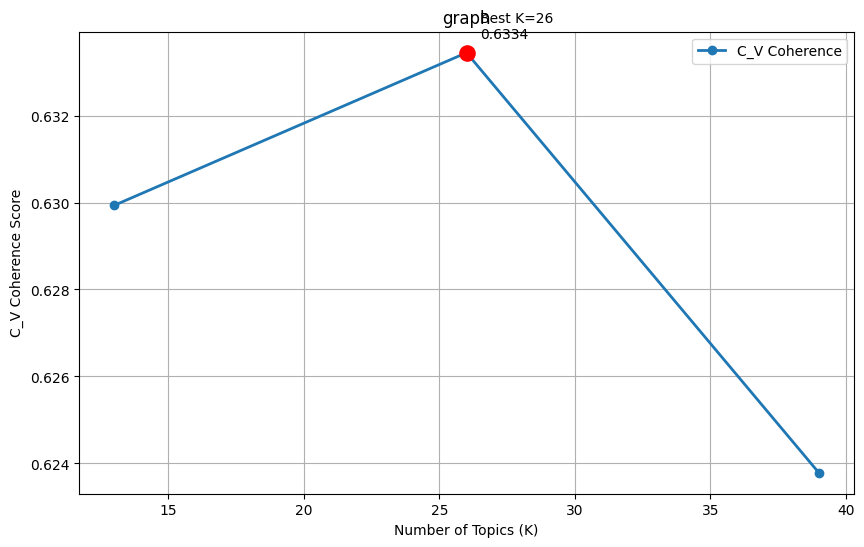

In [ ]:
import matplotlib.pyplot as plt

k_values = [k for k, score in results]
coherence_scores = [score for k, score in results]

best_k, best_score = max(results, key=lambda x: x[1])

plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    coherence_scores,
    marker='o',
    linewidth=2,
    label='C_V Coherence'
)

# Highlight the best point
plt.scatter(best_k, best_score, s=120, color='red', zorder=5)

plt.annotate(
    f"Best K={best_k}\n{best_score:.4f}",
    (best_k, best_score),
    textcoords="offset points",
    xytext=(10,10)
)

plt.xlabel("Number of Topics (K)")
plt.ylabel("C_V Coherence Score")
plt.title("graph")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
best_k, best_score = max(results, key=lambda x: x[1])

In [ ]:
from copy import deepcopy

#final_k = min(best_k, 25)
final_k = best_k

final_model = deepcopy(topic_model)

final_model.reduce_topics(
    processed_docs,
    nr_topics=final_k
)

print(f"Final model created with K = {final_k}")

2026-07-03 07:09:15,129 - BERTopic - Topic reduction - Reducing number of topics
2026-07-03 07:09:15,139 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-03 07:09:15,591 - BERTopic - Representation - Completed ✓
2026-07-03 07:09:15,593 - BERTopic - Topic reduction - Reduced number of topics from 47 to 26


Final model created with K = 26


In [ ]:
# ==========================================================
# STEP 7 : Automatic Topic Label Generation
# ==========================================================

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-3B-Instruct"

# ----------------------------------------------------------
# Load Tokenizer
# ----------------------------------------------------------

tokenizer = AutoTokenizer.from_pretrained(model_name)

# ----------------------------------------------------------
# Detect Device
# ----------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

print("=" * 50)
print("CUDA Available :", torch.cuda.is_available())
print("Using Device   :", device)
print("=" * 50)

# ----------------------------------------------------------
# Load Model
# ----------------------------------------------------------

if device == "cuda":

    # GPU Version
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        device_map="auto",
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True
    )

else:

    # CPU Version
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.float32,
        low_cpu_mem_usage=True
    )

    model.to(device)

print("=" * 50)
print("Model Loaded Successfully")
print("Model Device :", next(model.parameters()).device)
print("=" * 50)

CUDA Available : True
Using Device   : cuda


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Model Loaded Successfully
Model Device : cuda:0


In [ ]:
print(torch.cuda.is_available())
print(model.device)

True
cuda:0


In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch



tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

In [ ]:
import re
import torch

def generate_theme(keywords, representative_document):

    # Top 5 keywords are enough
    keywords = ", ".join(keywords[:5])

    # Representative document ko chhota rakho
    representative_document = representative_document[:250]

    prompt = f"""
Generate ONLY ONE topic label.

Rules:
- Maximum 2 words
- No explanation
- No sentence
- General research domain
- Don't repeate input themes
- Don't use company names, country names, organization names, or person names.
- Infer the underlying research domain from the keywords and document.
- Return only the label.
- Do not use punctuation.
- Use Title Case.
- Do not write a sentence.
- Do not explain.
- Don't use short forms use full forms like Us ,Le.
- proper spacing betbeen to meaningful words.
- Don't ude country , continent names like hong kong.
- Don't use single letters instent of this use amy meaning full word.
- Don't use short forms like Int etc.
- Don't use keywords like  Hong Kong etc.

Examples:

Input:

Keywords:
{keywords}

Document:
{representative_document}

Label:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(model.device)

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False,
            num_beams=1,
            repetition_penalty=1.2,
            pad_token_id=tokenizer.eos_token_id
        )

    theme = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Sirf "Label:" ke baad ka text lo
    if "Label:" in theme:
        theme = theme.split("Label:")[-1]
    theme = re.sub(r"[^A-Za-z\s]", " ", theme)

    # Split CamelCase
    theme = re.sub(r"([a-z])([A-Z])", r"\1 \2", theme)

    # Remove extra spaces
    theme = " ".join(theme.split())

    # Keep only first 2 words
    theme = " ".join(theme.split()[:2])

    return theme.title()





In [ ]:
# ==========================================================
# Display Final Topics with Themes and Keywords
# ==========================================================

# Dictionary to store generated theme labels.
topic_labels = {}

# Retrieve representative documents.
representative_docs = final_model.get_representative_docs()

# Iterate through all topics.
for topic_id in final_model.get_topics():

    # Skip the outlier topic.
    if topic_id == -1:
        continue

    # Retrieve the top 10 keywords.
    keywords = [
        word
        for word, score
        in final_model.get_topic(topic_id)[:10]
    ]

    # Retrieve the representative document.
    rep_doc = representative_docs.get(
        topic_id,
        [""]
    )[0]

    # Generate the theme.
    theme = generate_theme(
        keywords,
        rep_doc
    )

    # Store the generated theme.
    topic_labels[topic_id] = theme

    # Display the results.
    print("=" * 100)
    print(f"Topic ID : {topic_id}")
    print(f"Theme    : {theme}")
    print(f"Keywods : {', '.join(keywords)}")

Topic ID : 0
Theme    : Factory Automation
Keywods : factory, schneider, twin, electric, dassault, industrial, virtual, saudi, france, siemen
Topic ID : 1
Theme    : Renewable
Keywods : adani, visakhapatnam, renewable, hub, campus, capacity, adaniconnex, water, andhra, gigawatt
Topic ID : 2
Theme    : Global Leaders
Keywods : summit, minister, modi, prime, gate, delhi, pradesh, naidu, andhra, narendra
Topic ID : 3
Theme    : Reliance Network
Keywods : reliance, jio, ambani, meta, jamnagar, ril, mukesh, agm, indian, crore
Topic ID : 4
Theme    : Media Snapshot
Keywods : quarter, net, worth, territory, cash, gaap, age, income, total, currency
Topic ID : 5
Theme    : Infosys Performance
Keywods : infosys, infosy, statement, infy, topaz, client, uncertainty, assessment, filing, margin
Topic ID : 6
Theme    : Trump Administration
Keywods : trump, administration, prize, professor, america, award, white, european, infosys, watch
Topic ID : 7
Theme    : Siemens Digital
Keywods : siemen, dotmat

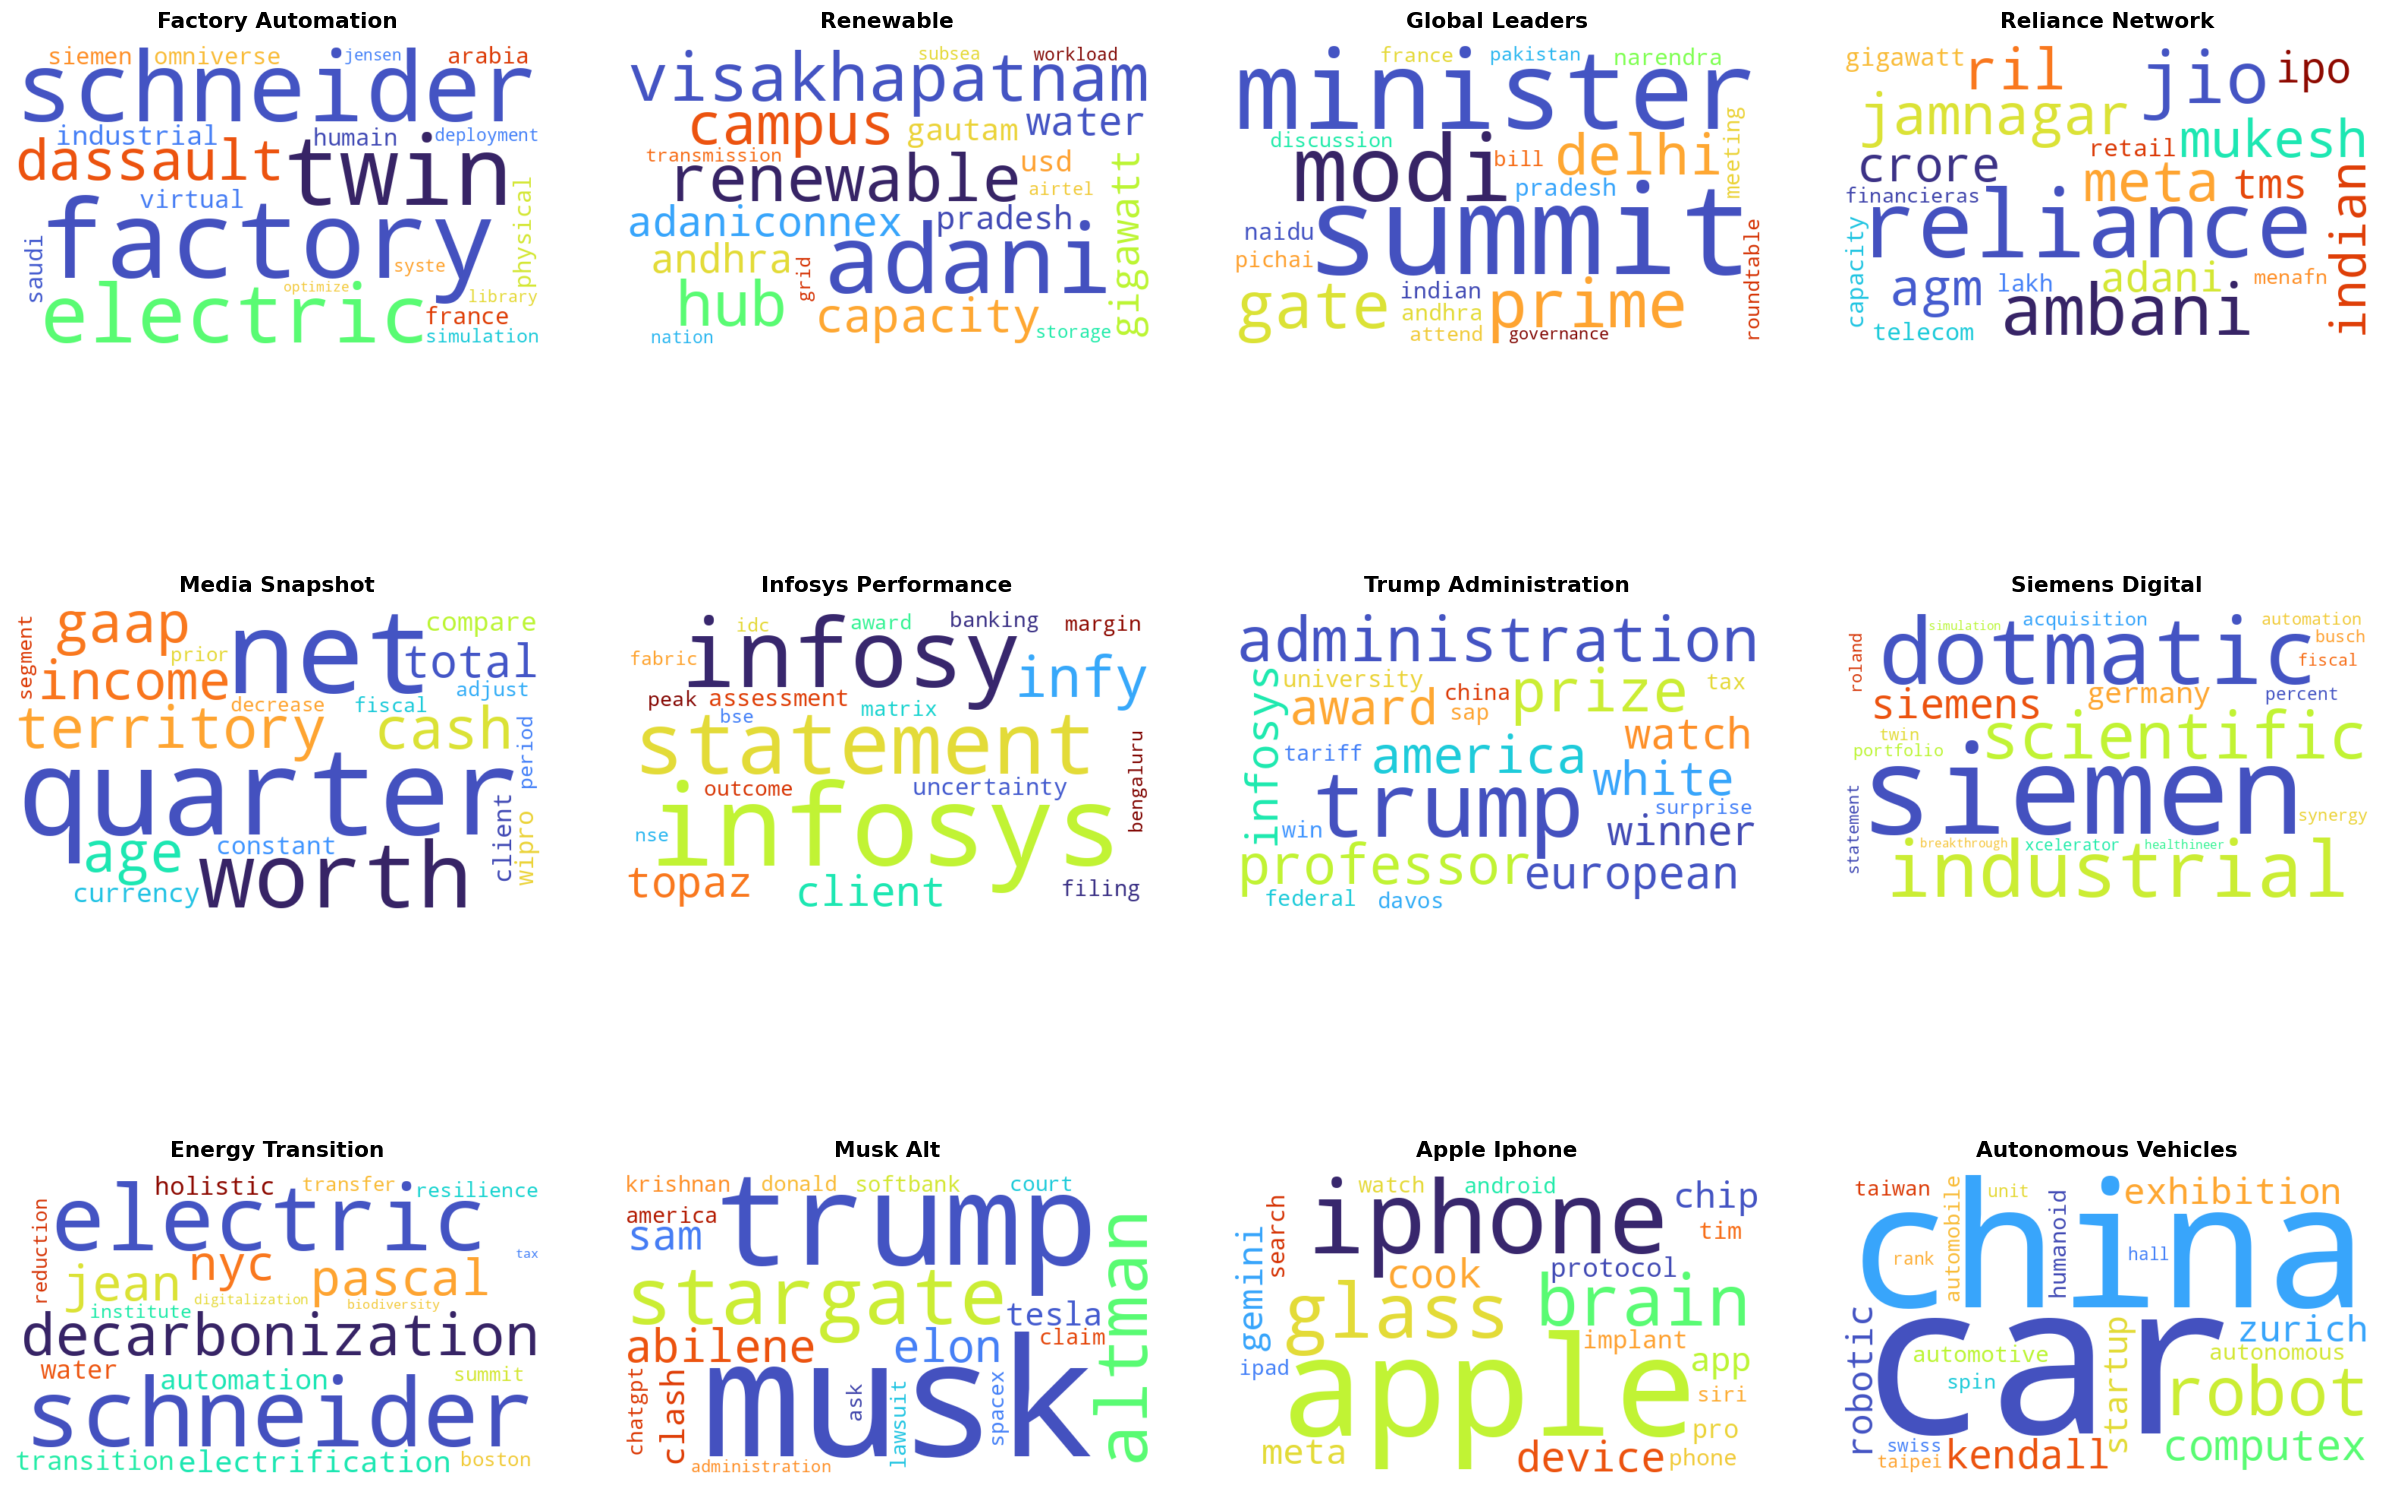

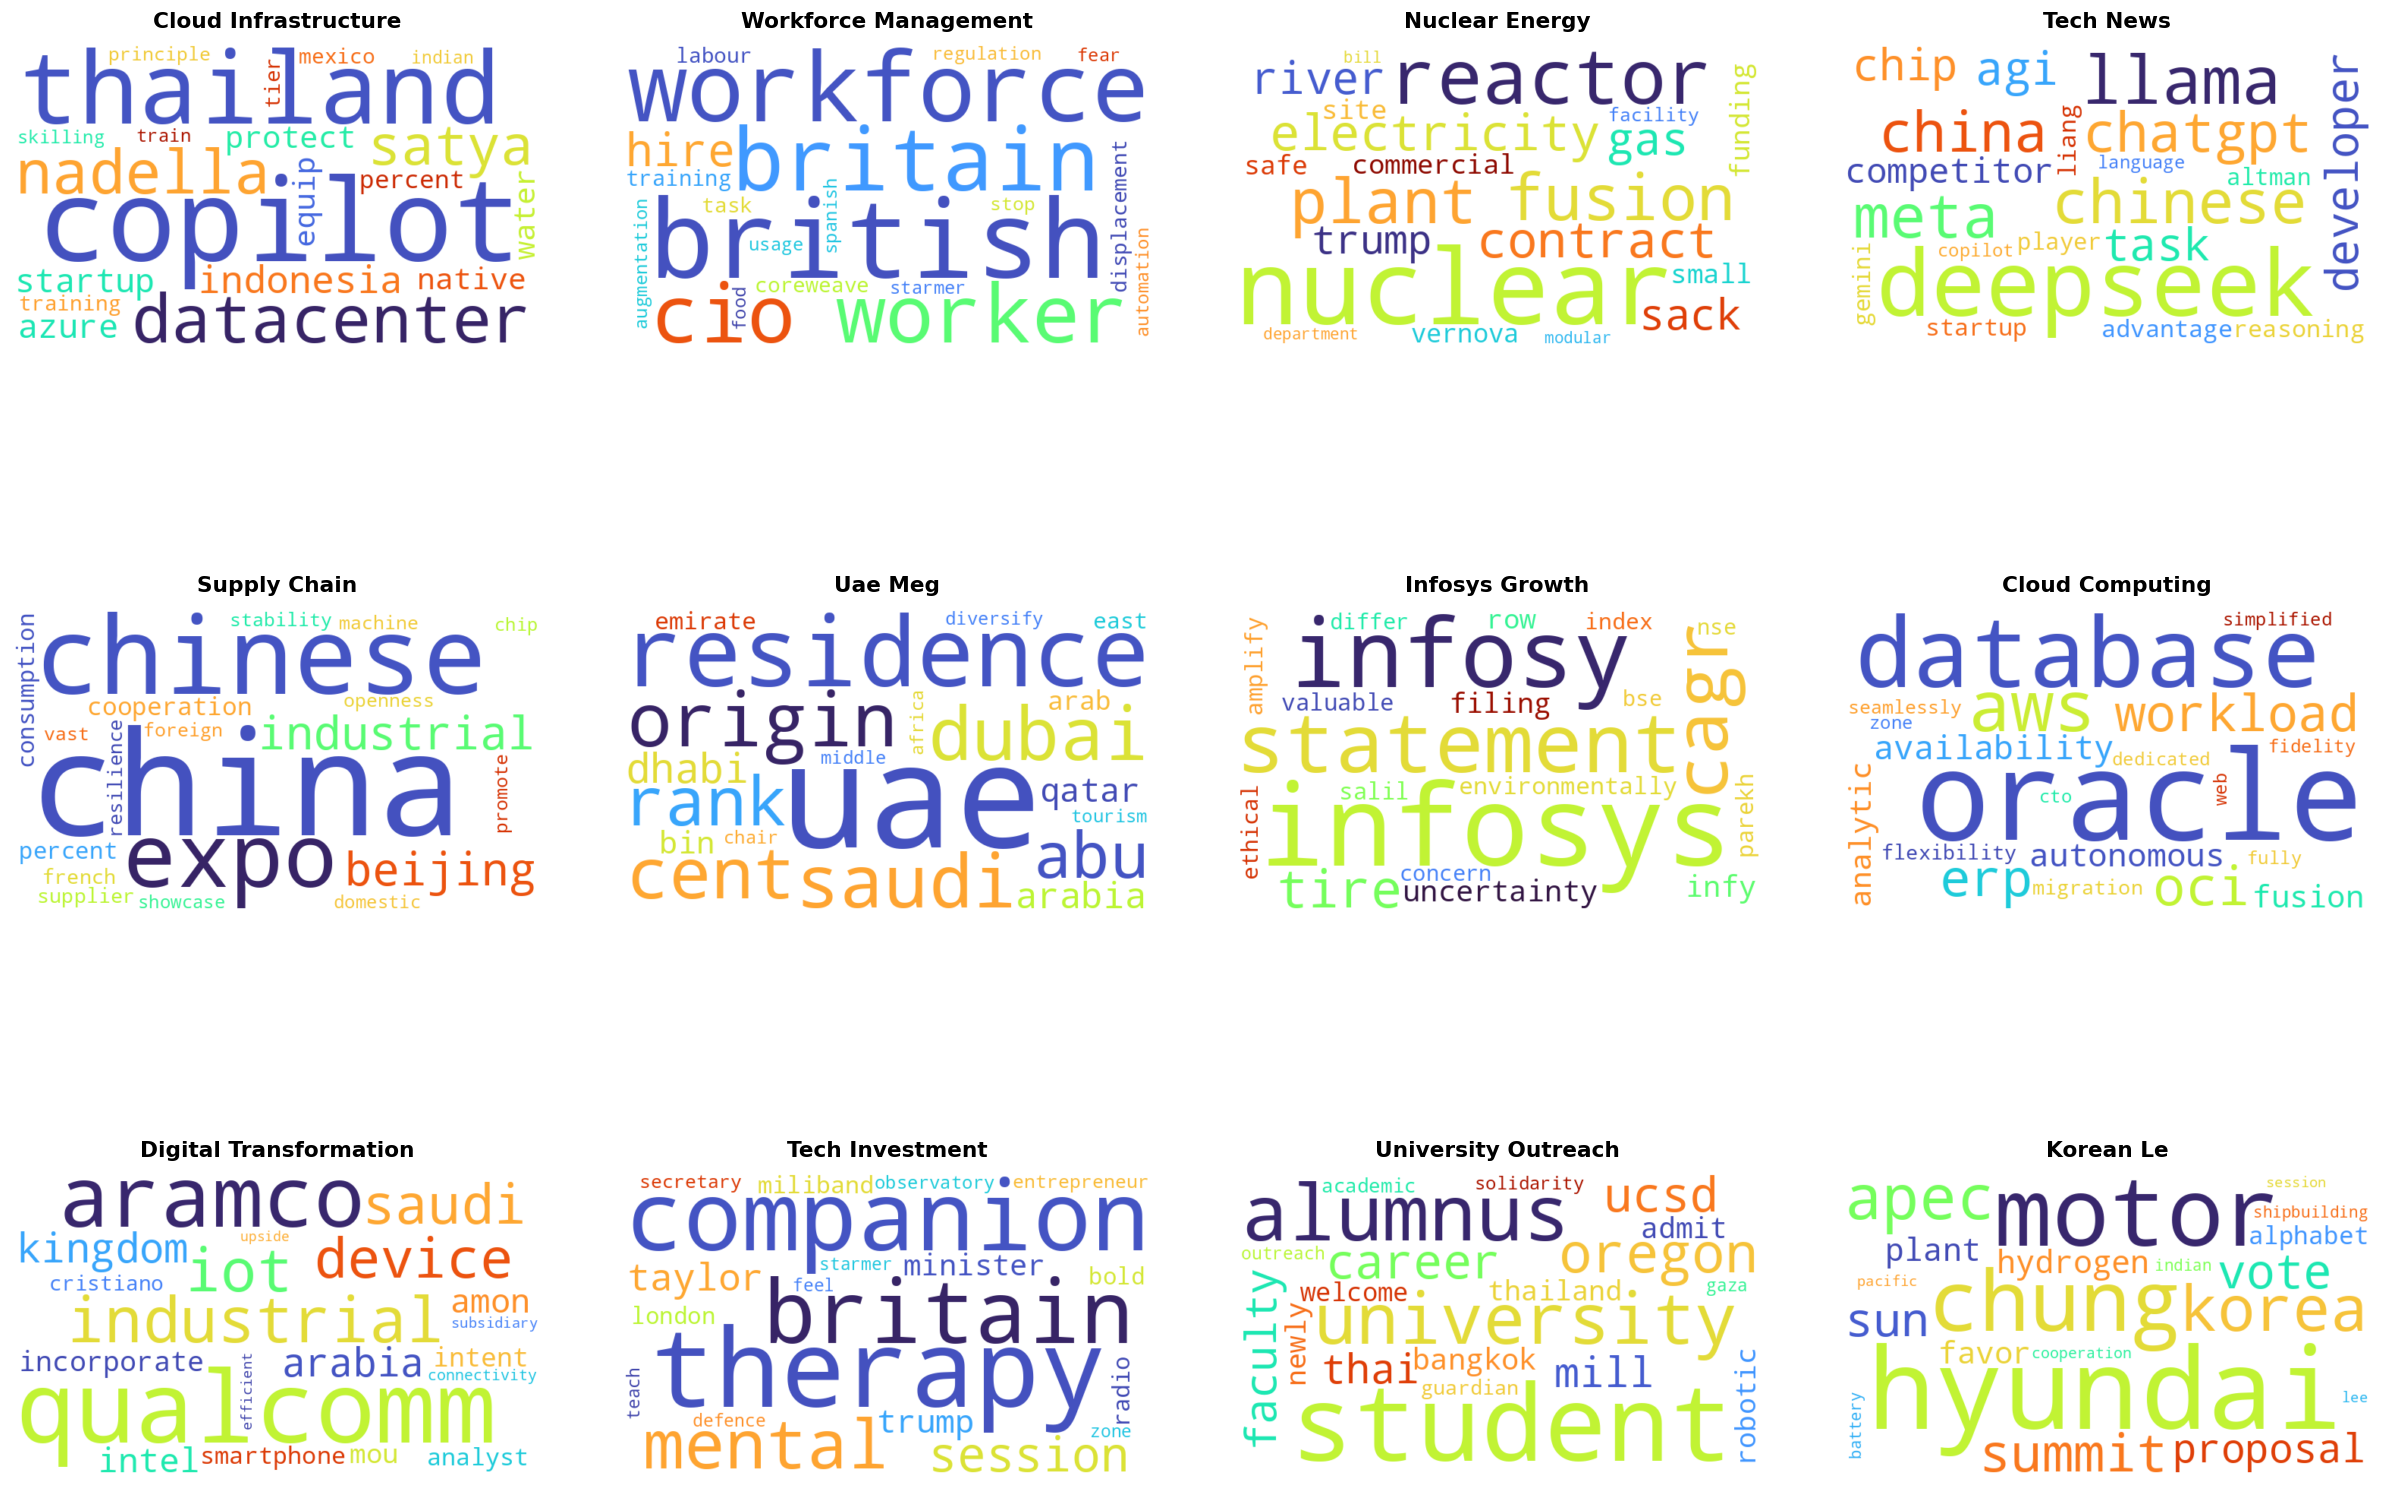

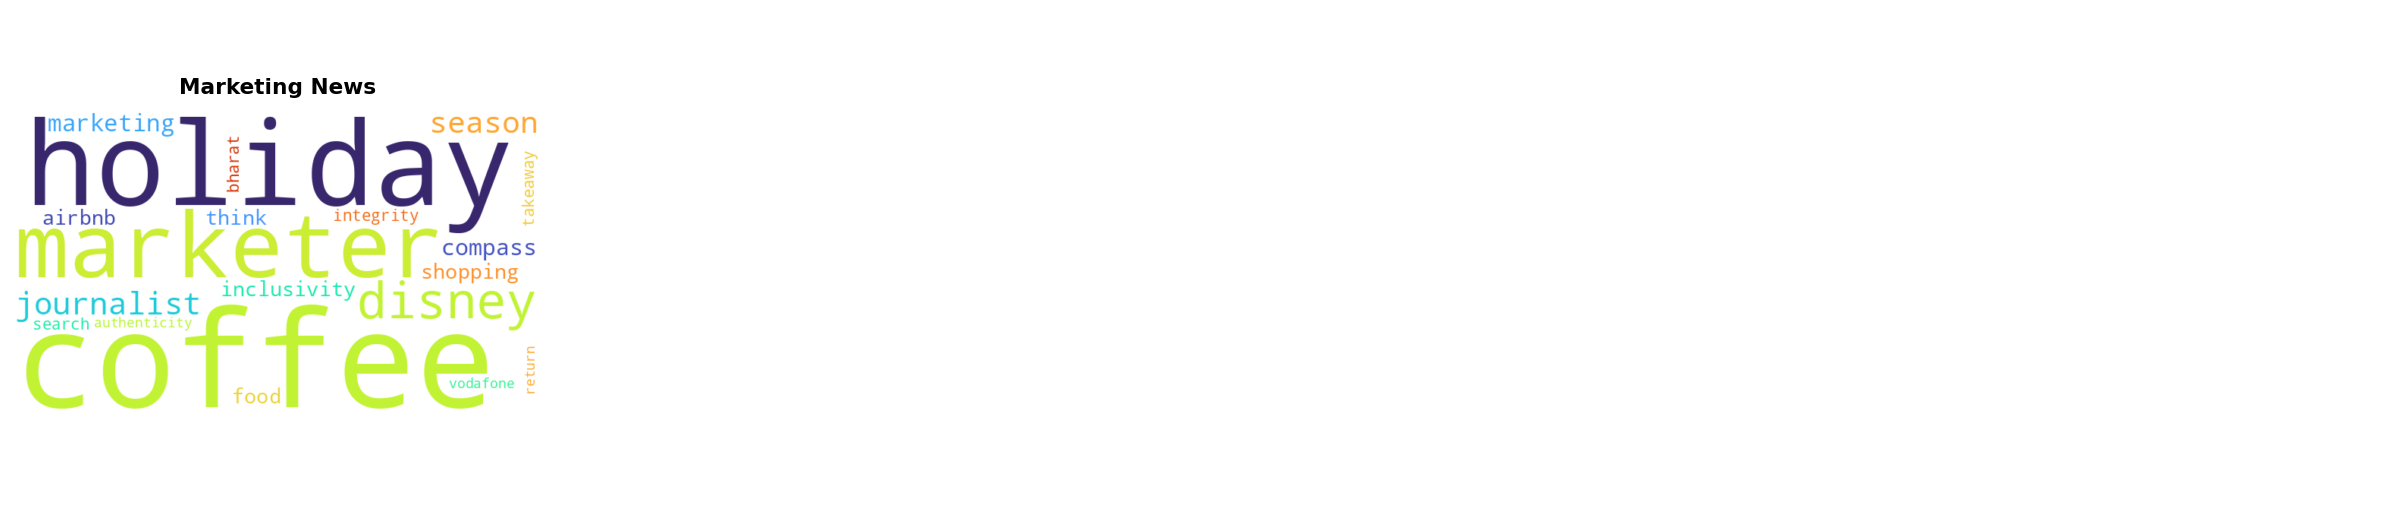

In [ ]:
# ==========================================================
# Generate Topic-wise Word Clouds (Optimized)
# ==========================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt
import math

# Representative documents
representative_docs = final_model.get_representative_docs()

# Valid topic IDs
topic_ids = [
    topic_id
    for topic_id in final_model.get_topics()
    if topic_id != -1
]

# ----------------------------------------------------------
# Settings
# ----------------------------------------------------------

columns = 4
topics_per_page = 12          # 3 rows × 4 columns

# ----------------------------------------------------------
# Plot page by page
# ----------------------------------------------------------

for start in range(0, len(topic_ids), topics_per_page):

    current_topics = topic_ids[start:start + topics_per_page]

    rows = math.ceil(len(current_topics) / columns)

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(columns * 5, rows * 4.5),
        dpi=120
    )

    # Convert axes to list
    if rows == 1 and columns == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # ------------------------------------------------------
    # Generate Word Clouds
    # ------------------------------------------------------

    for index, topic_id in enumerate(current_topics):

        topic_keywords = final_model.get_topic(topic_id)

        keywords = [
            word
            for word, score in topic_keywords[:10]
        ]

        rep_doc = representative_docs.get(
            topic_id,
            [""]
        )[0]

        # Generate theme (same function)
        theme = generate_theme(
            keywords,
            rep_doc
        )

        # Frequency dictionary
        word_frequencies = dict(topic_keywords)

        # Word Cloud
        wordcloud = WordCloud(
            width=700,
            height=400,
            background_color="white",
            colormap="turbo",
            max_words=40,
            scale=1,
            margin=8,
            contour_width=1,
            contour_color="black",
            prefer_horizontal=0.9,
            random_state=42
        ).generate_from_frequencies(word_frequencies)

        axes[index].imshow(
            wordcloud,
            interpolation="bilinear"
        )

        axes[index].axis("off")

        axes[index].set_title(
            theme,
            fontsize=13,
            fontweight="bold",
            pad=10
        )

    # ------------------------------------------------------
    # Hide unused plots
    # ------------------------------------------------------

    for i in range(len(current_topics), len(axes)):
        axes[i].axis("off")

    fig.tight_layout(pad=1.2)

    fig.subplots_adjust(
        hspace=0.25,
        wspace=0.15
    )

    plt.show()

    # Free memory
    plt.close(fig)

In [ ]:
# ==========================================================
# Count News Articles by Country from RTF Files
# ==========================================================

# Import required libraries.
import os
import re
from collections import Counter
from striprtf.striprtf import rtf_to_text

# Specify the folder containing the RTF files.
folder_path = "/content/drive/MyDrive/LexisNexis_01july2026/New1"

# List of countries to search.
countries = [
    "India", "China", "United States", "USA", "United Kingdom",
    "UK", "Germany", "France", "Japan", "Singapore",
    "Canada", "Australia", "UAE", "Saudi Arabia",
    "South Korea", "North Korea", "Taiwan", "Malaysia",
    "Indonesia", "Thailand", "Vietnam", "Philippines",
    "Italy", "Spain", "Brazil", "Mexico", "Russia",
    "Ukraine", "Pakistan", "Bangladesh", "Nepal",
    "Sri Lanka", "Qatar", "Oman", "Kuwait",
    "Bahrain", "Turkey", "Israel", "Iran"
]

# Initialize the country counter.
country_counter = Counter()

# Scan every RTF file.
for filename in os.listdir(folder_path):

    if filename.lower().endswith(".rtf"):

        file_path = os.path.join(folder_path, filename)

        # Read the RTF file.
        with open(file_path, "r", encoding="utf-8", errors="ignore") as file:

            text = rtf_to_text(file.read()).lower()

        # Store unique countries found in the current document.
        found_countries = set()

        # Search every country.
        for country in countries:

            if re.search(
                r"\b" + re.escape(country.lower()) + r"\b",
                text
            ):

                found_countries.add(country)

        # Increase the count only once per document.
        for country in found_countries:

            country_counter[country] += 1

# ==========================================================
# Display Country-wise News Count
# ==========================================================

print("=" * 50)
print("Country\t\tNews Count")
print("=" * 50)

for country, count in country_counter.most_common():

    print(f"{country:20s} {count}")

Country		News Count
India                387
China                170
UK                   146
United States        144
Germany              91
France               80
Japan                68
Australia            65
Saudi Arabia         57
Taiwan               50
USA                  49
Canada               47
Singapore            47
South Korea          43
Israel               35
UAE                  34
Spain                33
Mexico               32
Thailand             31
Brazil               31
Ukraine              30
Italy                27
Iran                 26
United Kingdom       26
Malaysia             24
Russia               22
Philippines          18
Indonesia            17
Vietnam              14
Pakistan             11
Qatar                11
Bahrain              5
Turkey               4
Oman                 4
Sri Lanka            4
Kuwait               2
Bangladesh           2
North Korea          2
Nepal                1


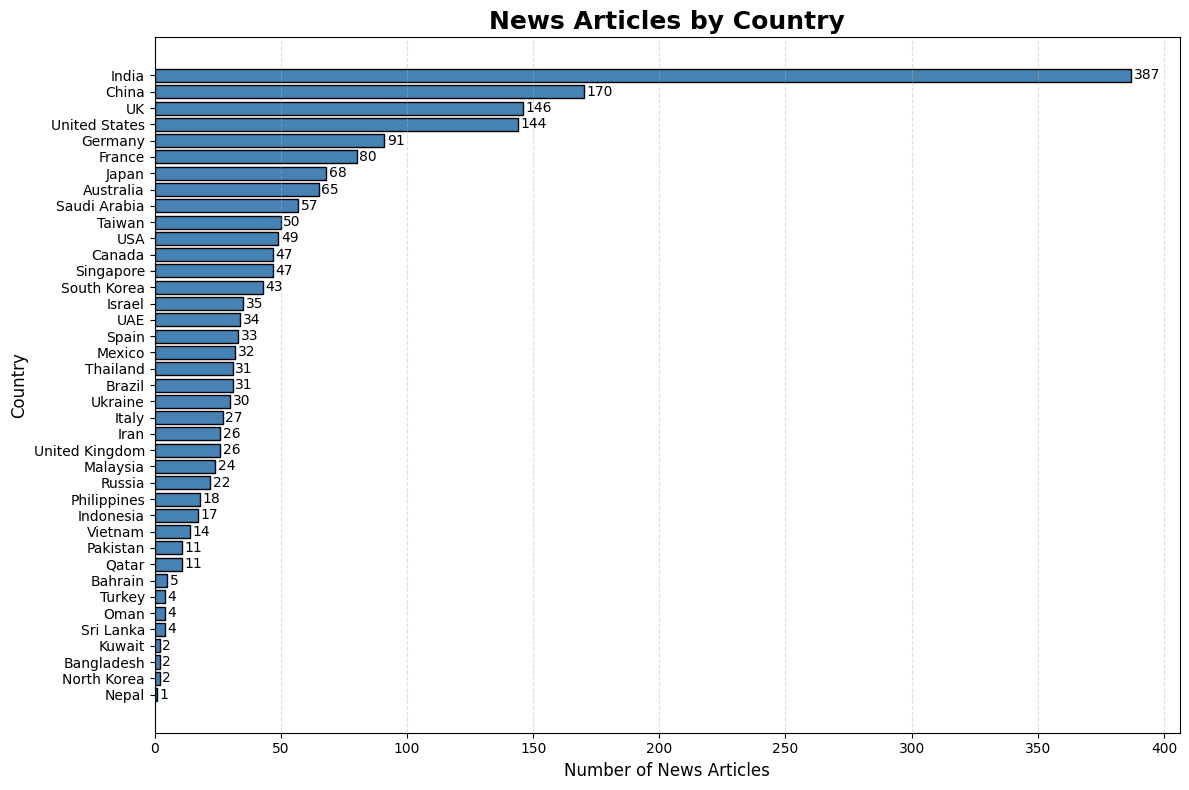

In [ ]:
# ==========================================================
# Visualize News Count by Country
# ==========================================================

# Import required libraries.
import matplotlib.pyplot as plt

# Sort countries by news count.
sorted_countries = country_counter.most_common()

# Separate country names and counts.
countries = [item[0] for item in sorted_countries]
counts = [item[1] for item in sorted_countries]

# Create the figure.
plt.figure(figsize=(12, 8))

# Create a horizontal bar chart.
bars = plt.barh(
    countries,
    counts,
    color="steelblue",
    edgecolor="black"
)

# Display the count on each bar.
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 1,
        bar.get_y() + bar.get_height()/2,
        str(int(width)),
        va="center",
        fontsize=10
    )

# Add chart title.
plt.title(
    "News Articles by Country",
    fontsize=18,
    fontweight="bold"
)

# Label the axes.
plt.xlabel(
    "Number of News Articles",
    fontsize=12
)

plt.ylabel(
    "Country",
    fontsize=12
)

# Add grid lines.
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

# Show the country with the highest count at the top.
plt.gca().invert_yaxis()

# Adjust layout.
plt.tight_layout()

# Display the chart.
plt.show()

In [ ]:
final_model.visualize_heatmap()

In [ ]:
# ==========================================================
# Replace Topic IDs with Generated Theme Labels
# ==========================================================

# Create a dictionary for custom labels.
custom_labels = {}

for topic_id, theme in topic_labels.items():

    custom_labels[topic_id] = theme

# Update BERTopic with custom labels.
final_model.set_topic_labels(custom_labels)

In [ ]:
fig = final_model.visualize_barchart(
    top_n_topics=20,
    custom_labels=True
)

fig.show()

In [ ]:
# ==========================================================
# Create Labels Using the Top Keyword of Each Topic
# ==========================================================

topic_labels = []

for topic_id in final_model.get_topics():

    if topic_id == -1:
        continue

    # Retrieve the top keyword.
    keyword = final_model.get_topic(topic_id)[0][0]

    topic_labels.append(keyword)

In [ ]:
# ==========================================================
# Create Single Keyword Labels
# ==========================================================

labels = []

for topic_id in final_model.get_topics():

    if topic_id == -1:
        continue

    # Take only the first keyword of each topic.
    keyword = final_model.get_topic(topic_id)[0][0]

    labels.append(keyword)

In [ ]:
fig = final_model.visualize_hierarchy(
    custom_labels=labels,
    width=1400,
    height=900
)

fig.show()